In [1]:
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import os

data = pd.read_csv(os.path.join("..", "wide_sta_observations.csv"), parse_dates=["period_date"])
data.rename(columns={"period_date": "date"}, inplace=True)
metadata = pd.read_csv(os.path.join("..", "all_metadata.csv"))

target_variable = "66" 
target_lag = 2
lags = list(range(-2, 3)) 

train_start_date = "2000-01-01"
test_start_date = "2018-03-01" 
test_end_date = "2023-12-01"

test = data.loc[
    (data.date >= train_start_date) & 
    (data.date <= test_end_date)
].reset_index(drop=True)

print(f"Duomenų rėžių patikra: Nuo {test.date.min()} iki {test.date.max()}")

Duomenų rėžių patikra: Nuo 2000-01-01 00:00:00 iki 2023-12-01 00:00:00


# Modelio kūrimas

In [3]:
train_series = test.loc[
    (~pd.isna(test[target_variable])) & (test.date < test_start_date),
    target_variable
].reset_index(drop=True)

model = pm.auto_arima(
    train_series,
    start_p=0,
    max_p=5,
    start_q=0,
    max_q=5,
    stepwise=False,
    seasonal=False,
    stationary=True
)

ar_order = model.order[0]
ma_order = model.order[2]

In [5]:
dates = (
        pd.date_range(test_start_date, test_end_date, freq="3MS")
        .strftime("%Y-%m-%d")
        .tolist()
    )

actuals = list(test.loc[test.date.isin(dates), target_variable].values)

C:\Users\MigleV\AppData\Local\Temp\ipykernel_24892\32520634.py:7: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  actuals = list(test.loc[test.date.isin(dates), target_variable].values)


In [ ]:
pred_dict = {k: [] for k in lags}
for lag in lags:
    for date in dates:
        test_series = test.loc[test.date <= date, ["date", target_variable]]
        test_series.iloc[len(test_series)+lag-1-target_lag:,1] = np.nan # imituojamas informacijos prieinamumo laikotarpis
        
        test_series.loc[test_series.date == date,target_variable] = np.nan
        
        ts = test_series.loc[~pd.isna(test_series[target_variable])].reset_index(drop=True)
        ts_dates = ts.date
        ts_series = ts[target_variable]

        ts_model = pm.arima.ARIMA((ar_order, 0, ma_order), maxiter=200)
        preds = ts_model.fit_predict(ts_series)

        final_dates = pd.date_range(ts_dates[0], periods=len(ts_dates)+10, freq="3MS")
        final_preds = list(ts_series) + list(preds)
        final = pd.DataFrame({"date":final_dates, "preds":final_preds})
        pred = final.loc[final.date == date, "preds"].values[0]
        
        pred_dict[lag].append(pred)

In [ ]:
# METRIKŲ SKAIČIAVIMAS
performance = pd.DataFrame(columns=["Vintage", "RMSE", "MAE"])

for lag in lags:
    errors = np.array(actuals) - np.array(pred_dict[lag])
    
    rmse = np.sqrt(np.mean(errors ** 2))
    mae = np.mean(np.abs(errors))
    
    tmp = pd.DataFrame({
        "Vintage": lag,
        "RMSE": rmse,
        "MAE": mae
    }, index=[0])
    
    performance = pd.concat([performance, tmp]).reset_index(drop=True)

performance.round(4)

C:\Users\MigleV\AppData\Local\Temp\ipykernel_24892\947343960.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  performance = pd.concat([performance, tmp]).reset_index(drop=True)


,Vintage,RMSE,MAE
0,-2,2.8429,1.8912
1,-1,2.8429,1.8912
2,0,2.9333,1.8861
3,1,2.9333,1.8861
4,2,2.9333,1.8861


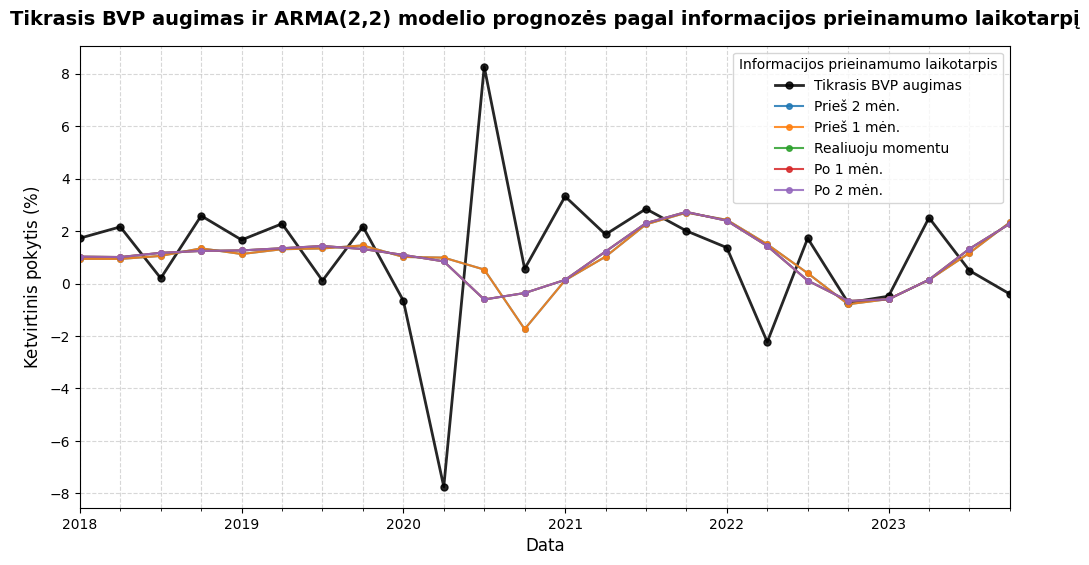

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

pred_dict_enet = pd.read_csv('predictions_arma.csv')
actuals = pred_dict_enet['actual']
dates = pred_dict_enet['date']

df_plot_enet = pd.DataFrame({
    "Tikrasis BVP augimas": actuals.values, 
    "Prieš 2 mėn.": pred_dict_enet['lag_-2'].values, 
    "Prieš 1 mėn.": pred_dict_enet['lag_-1'].values, 
    "Realiuoju momentu": pred_dict_enet['lag_0'].values,
    "Po 1 mėn.": pred_dict_enet['lag_1'].values,
    "Po 2 mėn.": pred_dict_enet['lag_2'].values
}, index=pd.to_datetime(dates))

# Grafikas
colors = ['black', 'C0', 'C1', 'C2', 'C3', 'C4']

ax = df_plot_enet.plot(
    figsize=(12, 6), 
    color=colors, 
    marker='o', 
    markersize=4, 
    linewidth=1.5, 
    alpha=0.85
)

ax.lines[0].set_linewidth(2)       
ax.lines[0].set_markersize(5)        

ax.lines[1].set_linestyle('-')       
ax.lines[2].set_linestyle('-')       
ax.lines[3].set_linestyle('-')       
ax.lines[4].set_linestyle('-')     
ax.lines[5].set_linestyle('-')      

plt.title("Tikrasis BVP augimas ir ARMA(2,2) modelio prognozės pagal informacijos prieinamumo laikotarpį", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Ketvirtinis pokytis ($\\%$)", fontsize=12)
plt.xlabel("Data", fontsize=12)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title="Informacijos prieinamumo laikotarpis", loc='upper right', fontsize=10)

plt.savefig('arma_nowcast_comparison.png', dpi=300, bbox_inches='tight')
plt.show() 

In [9]:
import json

df_preds_arma = pd.DataFrame(pred_dict)
df_preds_arma.columns = [f"lag_{c}" for c in df_preds_arma.columns]
df_preds_arma['date'] = dates
df_preds_arma['actual'] = actuals

df_preds_arma.to_csv('predictions_arma.csv', index=False)
print("ARMA prognozės sėkmingai išsaugotos į 'predictions_arma.csv'")

arma_params = {
    "ar_order": int(ar_order),
    "ma_order": int(ma_order),
    "seasonal": False,
    "stationary": True
}

with open('best_params_arma.json', 'w') as f:
    json.dump(arma_params, f, indent=4)
print("ARMA parametrai išsaugoti į 'best_params_arma.json'")

ARMA prognozės sėkmingai išsaugotos į 'predictions_arma.csv'
ARMA parametrai išsaugoti į 'best_params_arma.json'
